In [ ]:
# for saving training weights
from google.colab import drive
drive.mount('/content/drive')
import shutil

Mounted at /content/drive


In [ ]:
!nvidia-smi

Wed Jul 30 09:58:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.0/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
print({HOME})

{'/content'}


In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="PREtYuS13VXPKlpKYGKD")
project = rf.workspace("capstone-cra8x").project("citypersons-woqjq-ike0o-dtqfy")
version = project.version(1)
dataset = version.download("yolov8")


/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 86.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Citypersons-1 in yolov8:: 100%|██████████| 6962/6962 [00:04<00:00, 1551.57it/s]


## Custom Training

In [ ]:
print(dataset.location)

/content/datasets/Citypersons-1


In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 batch=16 device=0 patience=10 name="train_0915_"

/content
Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Citypersons-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_0915_, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspectiv

## Validate Custom Model

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train_0915_/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3080.9±731.0 MB/s, size: 198.1 KB)
val: Scanning /content/datasets/Citypersons-1/valid/labels.cache... 342 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 342/342 4.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.9it/s 7.6s
                   all        342       3414      0.451      0.219      0.244      0.145
                  None        281       1202      0.332     0.0416     0.0448     0.0131
                ignore         42         49      0.322     0.0204     0.0285     0.0165
                   ped        289       2163      0.698      0.596      0.659      0.404
Speed: 1.3ms preprocess, 5.8ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/run

## Inference with Custom Model

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train_0915_/weights/best.pt source={dataset.location}/test/images save=true

/content
Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

image 1/341 /content/datasets/Citypersons-1/test/images/aachen_000002_000019_leftImg8bit_png.rf.fb4b114d0b573cf6bb0a85130fb6a52c.jpg: 320x640 3 peds, 49.2ms
image 2/341 /content/datasets/Citypersons-1/test/images/aachen_000003_000019_leftImg8bit_png.rf.b7e8f36ea4590701f8e2c62981c36bd3.jpg: 320x640 (no detections), 10.5ms
image 3/341 /content/datasets/Citypersons-1/test/images/aachen_000004_000019_leftImg8bit_png.rf.c3e2a738d43c36b73f96cad7f7d8ed7d.jpg: 320x640 7 peds, 10.5ms
image 4/341 /content/datasets/Citypersons-1/test/images/aachen_000008_000019_leftImg8bit_png.rf.7ac575b86dd24472f21da0cd1aa2c39c.jpg: 320x640 2 Nones, 5 peds, 10.5ms
image 5/341 /content/datasets/Citypersons-1/test/images/aachen_000009_000019_leftImg8bit_png.rf.87da82fe21899a43dfa1710097f55e55.jpg: 320x640 1 None, 5 peds, 10.5ms
image 6/341 /c

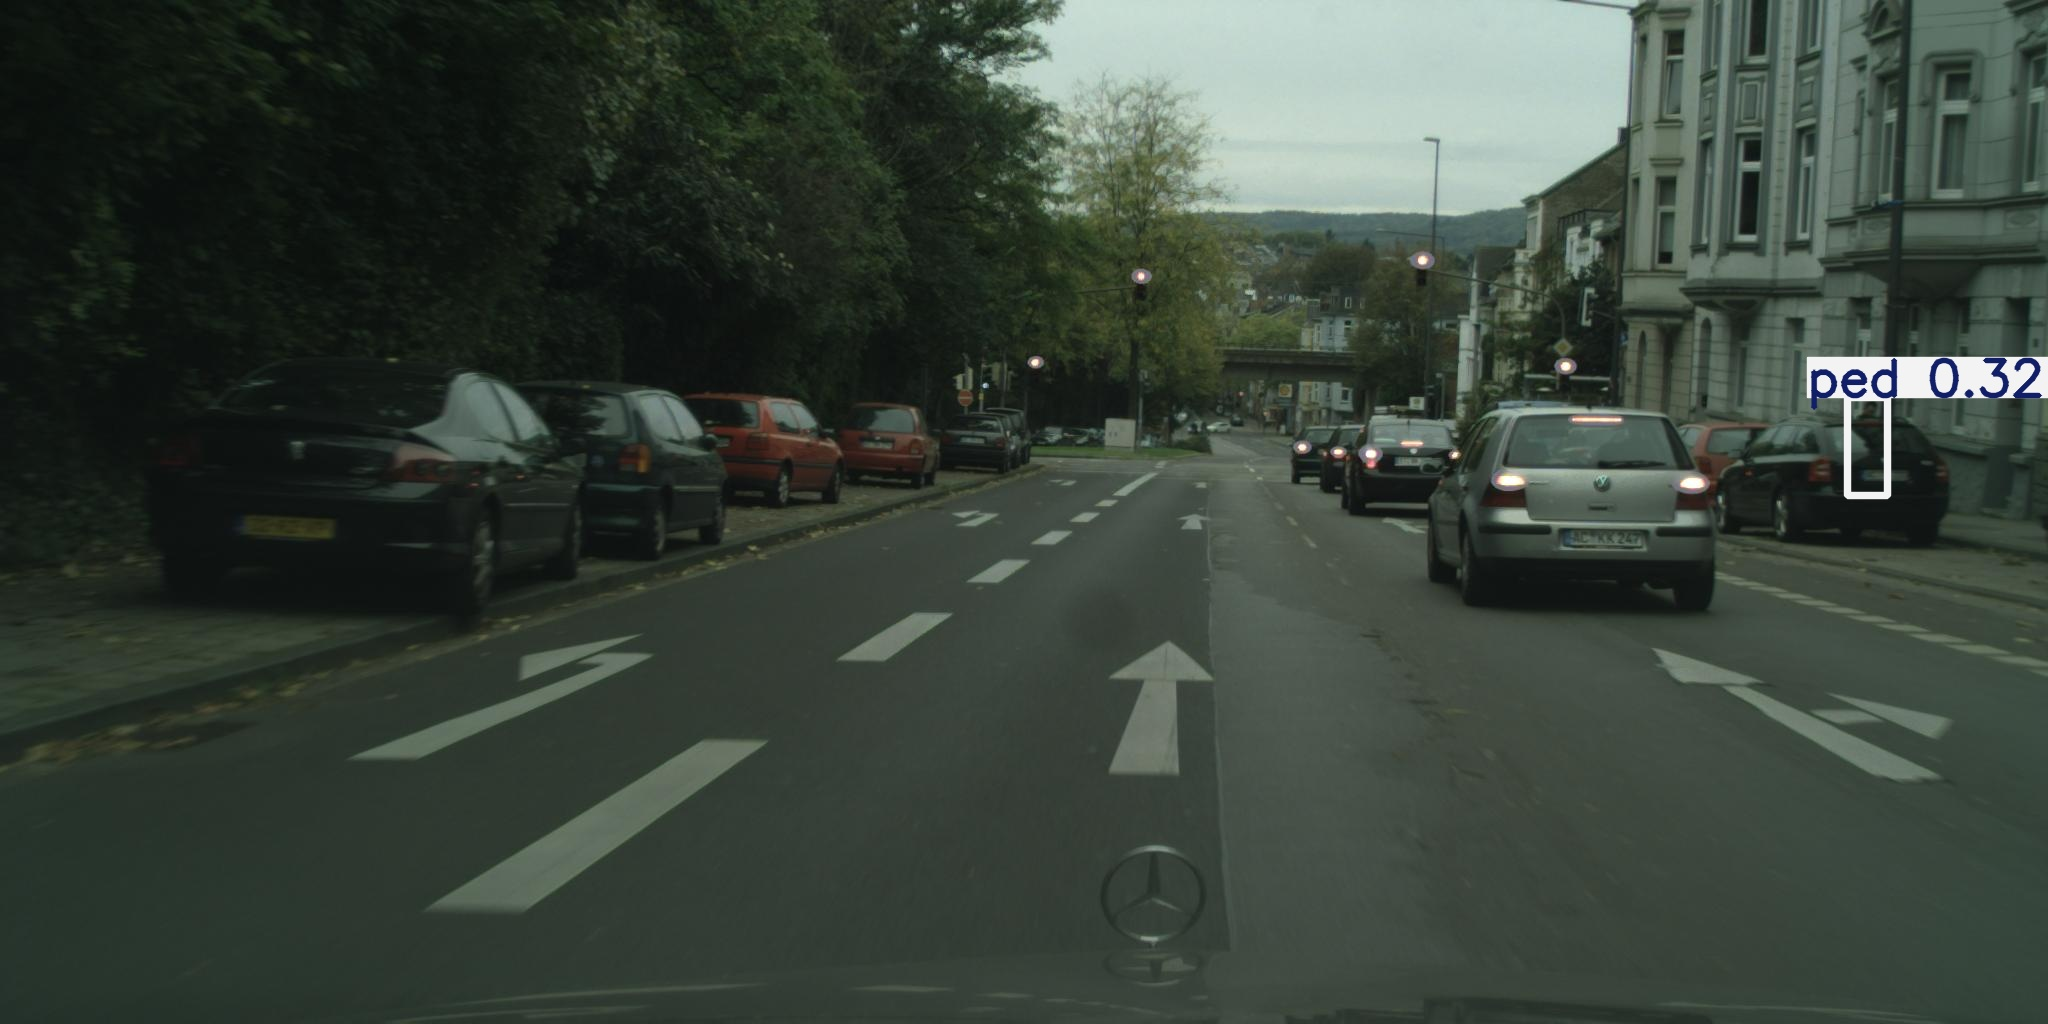

In [ ]:
Image(filename=f'/content/runs/detect/predict/aachen_000058_000019_leftImg8bit_png.rf.a832eb9567931485181cb11cf373722e.jpg', width=600)

In [ ]:
#detect with new weights, uniform img

%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train_0915_/weights/best.pt  source="/content/test_yolo.png" save=true

/content
Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/test_yolo.png: 384x640 3 peds, 43.0ms
Speed: 2.3ms preprocess, 43.0ms inference, 120.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


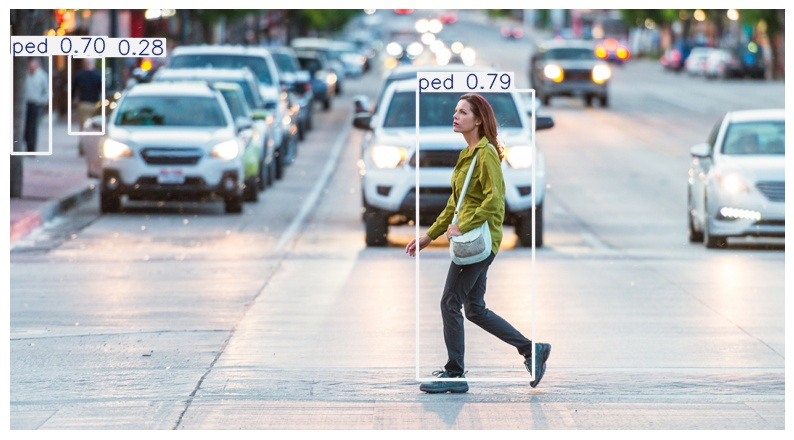

In [ ]:
Image(filename=f'/content/runs/detect/predict2/test_yolo.jpg', width=600)

In [ ]:
#detect with pretrained weights, uniform img

%cd {HOME}
!yolo task=detect mode=predict model=yolov8s.pt  source="/content/test_yolo.png" save=true

/content
Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs

image 1/1 /content/test_yolo.png: 384x640 4 persons, 15 cars, 1 handbag, 42.1ms
Speed: 2.0ms preprocess, 42.1ms inference, 144.2ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict3
💡 Learn more at https://docs.ultralytics.com/modes/predict


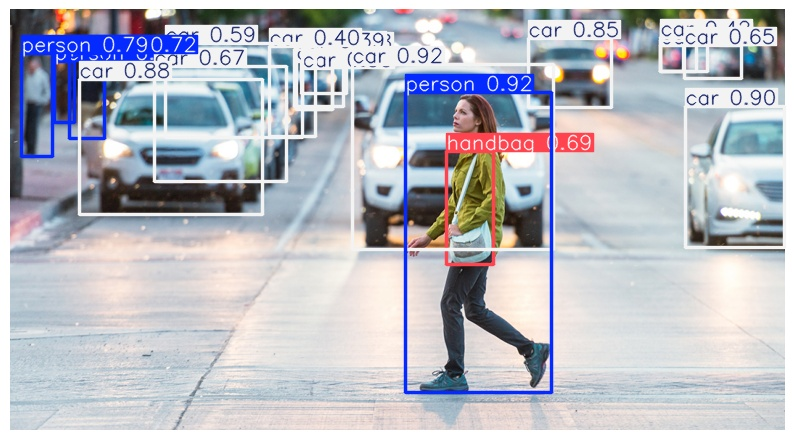

In [ ]:
Image(filename=f'/content/runs/detect/predict3/test_yolo.jpg', width=600)

In [ ]:
#path that contains folder you want to copy
%cd /content/drive/MyDrive/MLPR_new_runs/yolov8
%cp -av /content/runs /content/drive/MyDrive/MLPR_new_runs/yolov8

/content/drive/MyDrive/MLPR_new_runs/yolov8
'/content/runs' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs'
'/content/runs/detect' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs/detect'
'/content/runs/detect/train_0915_' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs/detect/train_0915_'
'/content/runs/detect/train_0915_/weights' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs/detect/train_0915_/weights'
'/content/runs/detect/train_0915_/weights/last.pt' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs/detect/train_0915_/weights/last.pt'
'/content/runs/detect/train_0915_/weights/best.pt' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs/detect/train_0915_/weights/best.pt'
'/content/runs/detect/train_0915_/args.yaml' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs/detect/train_0915_/args.yaml'
'/content/runs/detect/train_0915_/labels.jpg' -> '/content/drive/MyDrive/MLPR_new_runs/yolov8/runs/detect/train_0915_/labels.jpg'
'/content/runs/detect/train_0915

/content


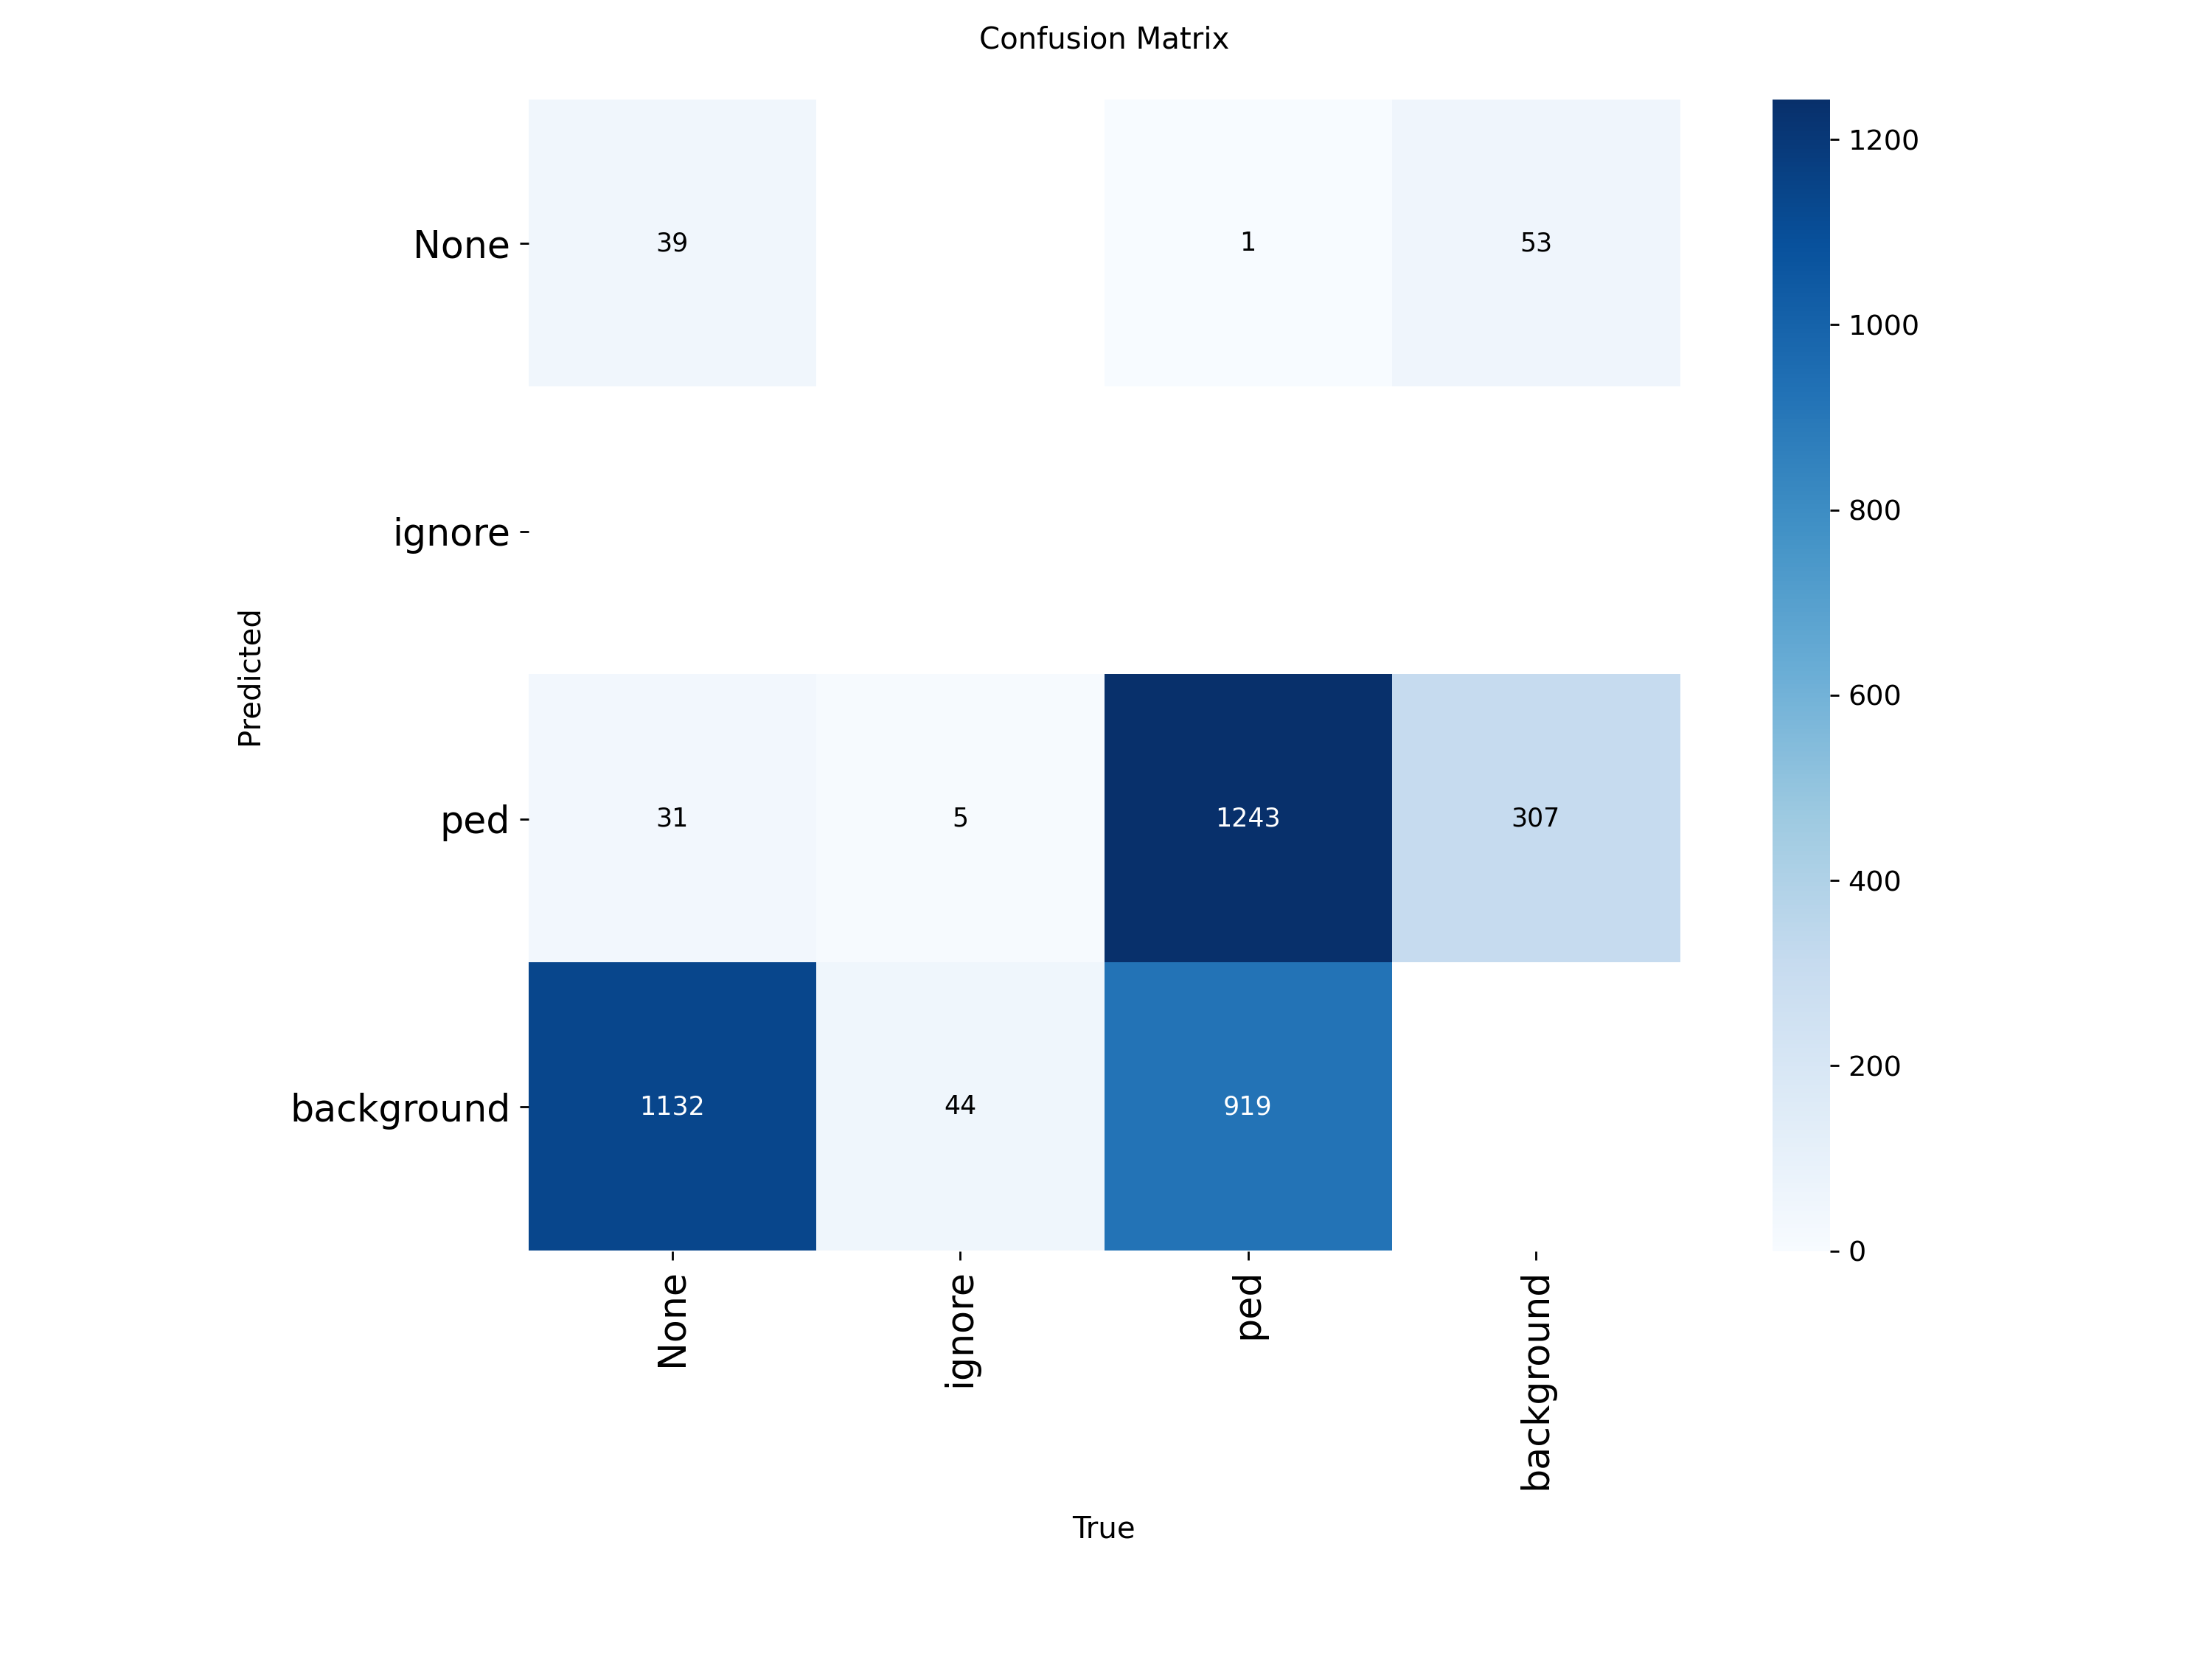

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train_0915_/confusion_matrix.png', width=600)

##Dataset

https://universe.roboflow.com/citypersons-conversion/citypersons-woqjq